<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

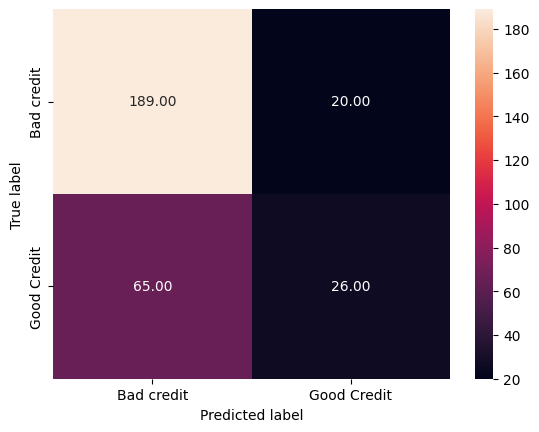

              precision    recall  f1-score   support

           0       0.57      0.29      0.38        91
           1       0.74      0.90      0.82       209

    accuracy                           0.72       300
   macro avg       0.65      0.60      0.60       300
weighted avg       0.69      0.72      0.68       300



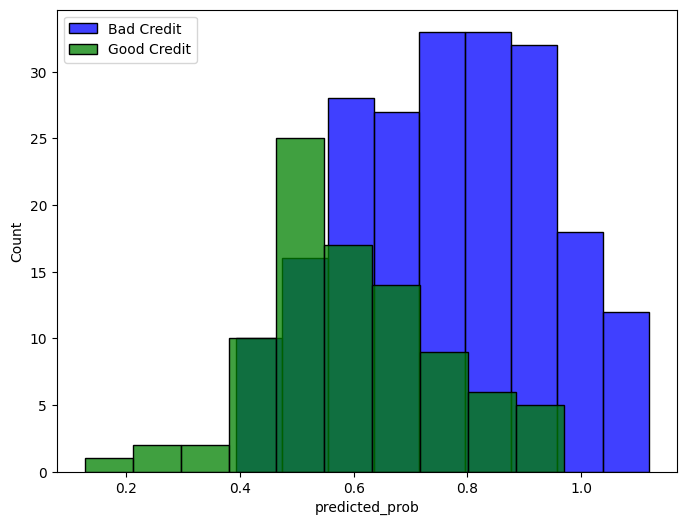

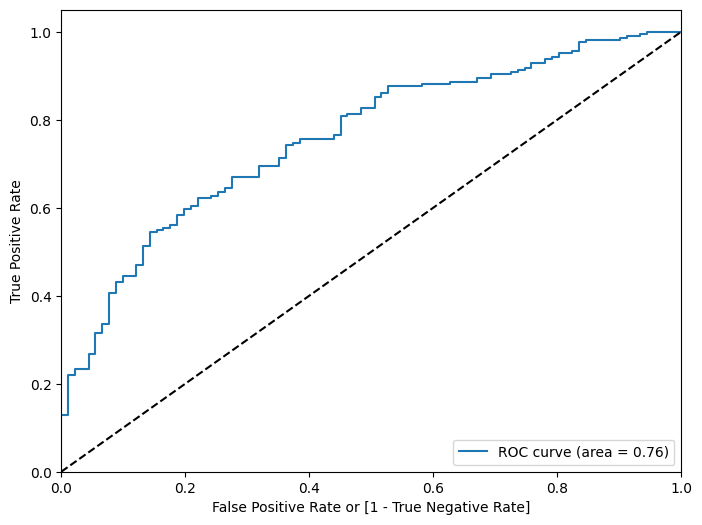

          tpr       fpr  thresholds      diff
127  0.545455  0.142857    0.761113  0.402597
150  0.622010  0.219780    0.707480  0.402229
143  0.598086  0.197802    0.731679  0.400284
126  0.540670  0.142857    0.761196  0.397813
149  0.617225  0.219780    0.710977  0.397445


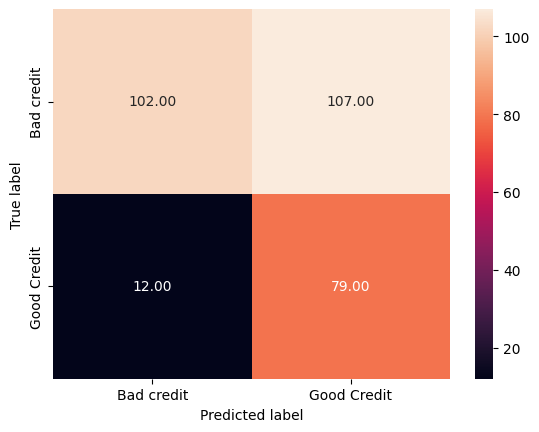

    prob  cost
27  0.37  86.0
26  0.36  86.0
29  0.39  86.0
28  0.38  86.0
24  0.34  87.0


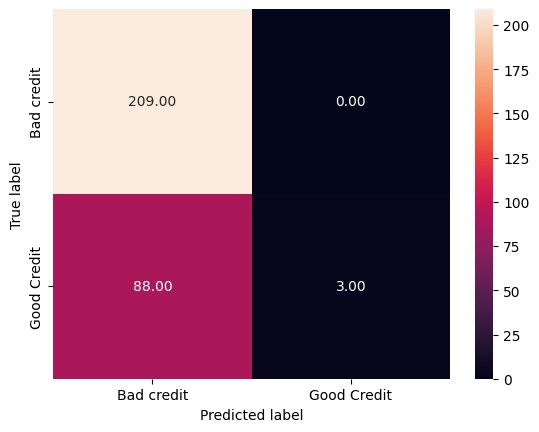

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

# Load and explore data
credit_df = pd.read_csv("GermanCredit.csv")
credit_df.info()

#print(credit_df.iloc[0:5, 0:8])
print(credit_df.status.value_counts())
#print(credit_df.iloc[0:5, 7:])
print(credit_df.property.value_counts())
print(credit_df.credit_risk.value_counts())

# Feature Selection
X_features = list(credit_df.columns)
X_features.remove('credit_risk') # Corrected variable name space
X_features

# Encoding Categorical Variables
encoded_credit_df = pd.get_dummies(credit_df[X_features], drop_first=True)
print(list(encoded_credit_df.columns))
bool_cols = encoded_credit_df.select_dtypes(include='bool').columns
encoded_credit_df[bool_cols] = encoded_credit_df[bool_cols].astype(int)
encoded_credit_df.info()

# Modeling
Y = credit_df.credit_risk
X = sm.add_constant(encoded_credit_df)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

logit = sm.Logit(y_train, X_train)
logit_model = logit.fit()
print(logit_model.summary2())

# Function to get significant variables
def get_significant_vars(lm):
    var_p_vals_df = pd.DataFrame(lm.pvalues)
    var_p_vals_df['vars'] = var_p_vals_df.index
    var_p_vals_df.columns = ['pvals', 'vars']
    return list(lm.pvalues[lm.pvalues <= 0.05].index)

significant_vars = get_significant_vars(logit_model)
print("thissssssssssssssssssssssss:",significant_vars)

# Final Model with significant variables
final_logit = sm.OLS(y_train, sm.add_constant(X_train[significant_vars])).fit()
print(final_logit.summary2())

# Predictions
y_pred_df = pd.DataFrame({
    "actual": y_test, 
    "predicted_prob": final_logit.predict(sm.add_constant(X_test[significant_vars]))
})

y_pred_df['predicted'] = y_pred_df.predicted_prob.map(lambda x: 1 if x > 0.5 else 0)
print(y_pred_df.sample(10, random_state=42))

# Confusion Matrix Function
def draw_cm(actual, predicted):
    cm = metrics.confusion_matrix(actual, predicted, labels=[1, 0])
    sn.heatmap(cm, annot=True, fmt='.2f', 
               xticklabels=["Bad credit", "Good Credit"], 
               yticklabels=["Bad credit", "Good Credit"])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

draw_cm(y_pred_df.actual, y_pred_df.predicted)
print(metrics.classification_report(y_pred_df.actual, y_pred_df.predicted))

# Distribution Plot

plt.figure(figsize=(8, 6))
sn.histplot(y_pred_df[y_pred_df.actual == 1]["predicted_prob"], kde=False, color='b', label='Bad Credit')
sn.histplot(y_pred_df[y_pred_df.actual == 0]["predicted_prob"], kde=False, color='g', label='Good Credit')
plt.legend()
plt.show()

# ROC Curve Function
def draw_roc(actual, probs):
    fpr, tpr, thresholds = metrics.roc_curve(actual, probs, drop_intermediate=False)
    auc_score = metrics.roc_auc_score(actual, probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()
    return fpr, tpr, thresholds


fpr, tpr, thresholds = draw_roc(y_pred_df.actual, y_pred_df.predicted_prob)

# Optimal Threshold Calculation (Youden's Index)
tpr_fpr = pd.DataFrame({'tpr': tpr, 'fpr': fpr, 'thresholds': thresholds})
tpr_fpr['diff'] = tpr_fpr.tpr - tpr_fpr.fpr
print(tpr_fpr.sort_values('diff', ascending=False)[0:5])

# Prediction with New Threshold
y_pred_df['predicted_new'] = y_pred_df.predicted_prob.map(lambda x: 1 if x > 0.78 else 0)
draw_cm(y_pred_df.actual, y_pred_df.predicted_new)

# Cost-based threshold optimization
def get_total_cost(actual, predicted, cost_FPs, cost_FNs):
    cm = metrics.confusion_matrix(actual, predicted, labels=[1, 0])
    cm_mat = np.array(cm)
    return cm_mat[0, 1] * cost_FNs + cm_mat[1, 0] * cost_FPs

cost_df = pd.DataFrame(columns=['prob', 'cost'])
idx = 0
for each_prob in range(10, 50):
    prob_val = each_prob / 100
    pred = y_pred_df.predicted_prob.map(lambda x: 1 if x > prob_val else 0)
    cost = get_total_cost(y_pred_df.actual, pred, 1, 5)
    cost_df.loc[idx] = [prob_val, cost]
    idx += 1

print(cost_df.sort_values('cost', ascending=True)[0:5])

# Final Prediction using Cost Optimization
y_pred_df['predicted_using_cost'] = y_pred_df.predicted_prob.map(lambda x: 1 if x > 0.29 else 0)
draw_cm(y_pred_df.actual, y_pred_df.predicted_using_cost)

